Last updated: 3/17/2026

# Setup

In [5]:
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pathlib import Path

# Inputs

- 35 Greyscale PNG TV Guides
- 6 Benchmarks
- 18 models

3 Total Pipeline Runs

# Load Data

In [6]:
# Load environment variables from .env file
load_dotenv("/home/users/ltdarc/ltdarc/LLM_benchmarks/.env")

BASE_DIR = os.getenv("BASE_DIR")

metrics_path = os.path.join(BASE_DIR, "outputs", "metrics", "metrics.json")

TypeError: expected str, bytes or os.PathLike object, not NoneType

In [3]:
metrics = pd.read_json(metrics_path, orient = 'records')
metrics['run_id'] = metrics['run_id'].fillna(0)

In [5]:
metrics[(metrics['model_name'] == 'gemini-2.5-pro') & (metrics['benchmark_name']== 'first_channel')]

,task_id,output,model_name,model_id,image_id,benchmark_name,benchmark_id,run_id,completion_tokens,total_tokens,input_cost,output_cost,input_tokens,input_dollar_cost,output_dollar_cost,total_dollar_cost,ground_truth,accuracy
160,2894,KHON,gemini-2.5-pro,13,24,first_channel,5,2.0,155,3554,2.5,15.0,3399,0.008497,0.002325,0.010822,2 3 003 2,0
192,2881,2 WCBS,gemini-2.5-pro,13,11,first_channel,5,1.0,149,3548,2.5,15.0,3399,0.008497,0.002235,0.010732,2 WCBS,1
458,2904,3,gemini-2.5-pro,13,34,first_channel,5,1.0,1643,5042,2.5,15.0,3399,0.008497,0.024645,0.033142,33,0
696,2887,WTVW,gemini-2.5-pro,13,17,first_channel,5,1.0,90,3489,2.5,15.0,3399,0.008497,0.001350,0.009848,7 WTVW,0
910,2903,WHTM,gemini-2.5-pro,13,33,first_channel,5,2.0,2231,5630,2.5,15.0,3399,0.008497,0.033465,0.041962,43 5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9530,2899,A&E,gemini-2.5-pro,13,29,first_channel,5,1.0,98,3497,2.5,15.0,3399,0.008497,0.001470,0.009967,A&E,1
9698,2877,2,gemini-2.5-pro,13,7,first_channel,5,1.0,496,3895,2.5,15.0,3399,0.008497,0.007440,0.015938,2,1
9797,2895,KHON,gemini-2.5-pro,13,25,first_channel,5,1.0,163,3562,2.5,15.0,3399,0.008497,0.002445,0.010942,2 3 003 2,0
9909,2903,WHTM,gemini-2.5-pro,13,33,first_channel,5,1.0,1396,4795,2.5,15.0,3399,0.008497,0.020940,0.029437,43 5,0


In [8]:
metrics[(metrics['benchmark_name']== 'first_channel') & (metrics['image_id']== 24)]["output"].value_counts()

output
KHON                  22
KGMB                   9
BROADCAST CHANNELS     3
2                      3
232                    3
ABC                    2
HBO                    2
2 KHON                 2
KHET                   1
PBS                    1
KHON 2                 1
Name: count, dtype: int64

In [9]:
metrics[(metrics['benchmark_name']== 'first_program') & (metrics['image_id']== 24)]["output"].value_counts()

output
Good Morning America                                                                                                                                                         13
Live With Regis and Kelly                                                                                                                                                     8
The Early Show                                                                                                                                                                4
News                                                                                                                                                                          3
Today                                                                                                                                                                         3
KHON 2 Morning News                                                                                              

# Summary Tables

In [52]:
# accuracy by model

accuracy_model = metrics.groupby(['model_name']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct_Outputs=('accuracy', 'sum'),
    Total_Outputs=('accuracy', 'count'),
    Total_Input_Cost=('input_dollar_cost', 'sum'),
    Total_Output_Cost=('output_dollar_cost', 'sum'),
    Total_Cost=('total_dollar_cost', 'sum')
).sort_values('Accuracy', ascending=False)

accuracy_model = accuracy_model.drop('claude-3-7-sonnet')

accuracy_model['Accuracy'] = accuracy_model['Accuracy'].map('{:.1%}'.format)
accuracy_model['Total_Input_Cost'] = accuracy_model['Total_Input_Cost'].map('${:.2f}'.format)
accuracy_model['Total_Output_Cost'] = accuracy_model['Total_Output_Cost'].map('${:.2f}'.format)
accuracy_model['Total_Cost'] = accuracy_model['Total_Cost'].map('${:.2f}'.format)
pd.set_option('display.max_rows', None)

top_8 = accuracy_model[['Accuracy', 'Total_Cost']].head(8)
bottom_8 = accuracy_model[['Accuracy', 'Total_Cost']].tail(8)

display(top_8)
display(bottom_8)

#display(accuracy_model[['Accuracy', 'Total_Cost']])

,Accuracy,Total_Cost
model_name,,
gemini-2.5-pro,71.9%,$8.76
Llama-4,64.6%,$1.36
gemini-2.0-flash-001,63.3%,$0.33
gpt-5,61.9%,$5.50
gpt-5.2,61.3%,$1.52
o1,61.0%,$41.35
gemini-2.0-flash-lite-001,60.6%,$0.15
gpt-5-mini,58.2%,$0.60


,Accuracy,Total_Cost
model_name,,
gpt-4o,57.6%,$1.95
claude-4-5-sonnet,56.7%,$4.63
gpt-4,56.5%,$7.81
gpt-4.1,56.2%,$1.56
claude-4-sonnet,55.7%,$4.11
claude-opus-4-6,55.4%,$8.49
gpt-4.omini,53.2%,$3.49
claude-3-haiku,51.0%,$0.35


In [53]:
# Accuracy per model by run
per_run = metrics.groupby(['model_name', 'run_id'])['accuracy'].mean()

# Total accuracy across all runs per model
total = metrics.groupby('model_name')['accuracy'].mean().rename('Average')

per_run = per_run.drop('claude-3-7-sonnet')
total = total.drop('claude-3-7-sonnet')

# Pivot so each run is a column
per_run_pivot = per_run.unstack('run_id')
per_run_pivot.columns = [f'Run_{int(c) + 1}' for c in per_run_pivot.columns]

# Combine
combined = pd.concat([per_run_pivot, total], axis=1)
combined = combined.sort_values('Average', ascending=False)

# Format
for col in combined.columns:
    combined[col] = combined[col].map('{:.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

,Run_1,Run_2,Run_3,Average
model_name,,,,
gemini-2.5-pro,72.4%,71.9%,71.4%,71.9%
Llama-4,63.8%,64.8%,65.2%,64.6%
gemini-2.0-flash-001,64.8%,61.9%,63.3%,63.3%
gpt-5,62.1%,61.8%,61.8%,61.9%
gpt-5.2,61.9%,61.4%,60.5%,61.3%
o1,60.2%,61.2%,61.7%,61.0%
gemini-2.0-flash-lite-001,60.5%,60.5%,61.0%,60.6%
gpt-5-mini,58.7%,57.2%,58.7%,58.2%
gpt-4o,58.6%,56.2%,58.1%,57.6%


In [ ]:
accuracy_benchmark = metrics.groupby(['benchmark_name']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct=('accuracy', 'sum'),
    Total=('accuracy', 'count'),
    Total_Cost=('total_dollar_cost', 'sum')
).sort_values('Accuracy', ascending=False)

In [ ]:
# by benchmark

accuracy_benchmark = metrics.groupby(['benchmark_name']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct=('accuracy', 'sum'),
    Total=('accuracy', 'count'),
    Total_Cost=('total_dollar_cost', 'sum')
).sort_values('Accuracy', ascending=False)

accuracy_benchmark['Accuracy'] = accuracy_benchmark['Accuracy'].map('{:.1%}'.format)
accuracy_benchmark['Total_Cost'] = accuracy_benchmark['Total_Cost'].map('${:.2f}'.format)
pd.set_option('display.max_rows', None)
display(accuracy_benchmark)

,Accuracy,Correct,Total,Total_Cost
benchmark_name,,,,
newspaper_name,99.3%,1701,1713,$10.44
newspaper_date,94.3%,1618,1715,$11.60
day_of_week,72.0%,1234,1715,$10.33
tv_guide_date,42.9%,735,1715,$15.03
first_channel,25.6%,432,1685,$18.46
first_program,19.7%,337,1715,$27.48


In [37]:
# Accuracy per model by run
per_run = metrics.groupby(['benchmark_name', 'run_id'])['accuracy'].mean()

# Total accuracy across all runs per model
total = metrics.groupby('benchmark_name')['accuracy'].mean().rename('Average')

# Pivot so each run is a column
per_run_pivot = per_run.unstack('run_id')
per_run_pivot.columns = [f'Run_{int(c) + 1}' for c in per_run_pivot.columns]

# Combine
combined = pd.concat([per_run_pivot, total], axis=1)
combined = combined.sort_values('Average', ascending=False)

# Format
for col in combined.columns:
    combined[col] = combined[col].map('{:.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

,Run_1,Run_2,Run_3,Average
benchmark_name,,,,
newspaper_name,99.5%,98.9%,99.5%,99.3%
newspaper_date,94.5%,94.3%,94.3%,94.3%
day_of_week,71.9%,71.6%,72.3%,72.0%
tv_guide_date,43.5%,42.1%,42.9%,42.9%
first_channel,24.9%,26.5%,25.6%,25.6%
first_program,20.2%,18.9%,19.8%,19.7%


In [38]:
# Accuracy per model by run
per_run = metrics.groupby(['benchmark_name', 'model_name', 'run_id'])['accuracy'].mean()

# Total accuracy across all runs per model
total = metrics.groupby(['benchmark_name','model_name'])['accuracy'].mean().rename('Average')

# Pivot so each run is a column
per_run_pivot = per_run.unstack('run_id')
per_run_pivot.columns = [f'Run_{int(c) + 1}' for c in per_run_pivot.columns]

# Combine
combined = pd.concat([per_run_pivot, total], axis=1)
combined['Std'] = combined[['Run_1', 'Run_2', 'Run_3']].std(axis=1)
combined = combined.sort_values('Std', ascending=False)

# Format
for col in combined.columns:
    combined[col] = combined[col].map('{:.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

Run_1   Run_2   Run_3 Average   Std
benchmark_name model_name                                                     
first_program  gemini-2.0-flash-001        48.6%   37.1%   42.9%   42.9%  5.7%
               gpt-5.2                     28.6%   20.0%   20.0%   22.9%  4.9%
first_channel  o1                          25.8%   25.8%   19.4%   23.7%  3.7%
day_of_week    gpt-4.1                     77.1%   71.4%   77.1%   75.2%  3.3%
first_channel  gpt-5.2                     14.3%   20.0%   20.0%   18.1%  3.3%
tv_guide_date  Llama-4                     37.1%   42.9%   42.9%   41.0%  3.3%
               gpt-4o                      45.7%   40.0%   45.7%   43.8%  3.3%
               gpt-4                       45.7%   45.7%   40.0%   43.8%  3.3%
day_of_week    gpt-5.2                     74.3%   77.1%   71.4%   74.3%  2.9%
               o1                          71.4%   74.3%   77.1%   74.3%  2.9%
first_program  gpt-5-mini                  14.3%    8.6%   11.4%   11.4%  2.9%
               o1                           8.6%   11.4%   14.3%   11.4%  2.9%
first_channel  gpt-4                        8.6%   14.3%   11.4%   11.4%  2.9%
               gpt-4.1                      8.6%   14.3%   11.4%   11.4%  2.9%
tv_guide_date  gpt-4.1                     45.7%   40.0%   42.9%   42.9%  2.9%
first_channel  gpt-5-mini                  12.9%   15.2%   18.2%   15.5%  2.6%
               gpt-5                       12.9%   15.6%   12.5%   13.7%  1.7%
newspaper_date gpt-4.omini                 88.6%   91.4%   91.4%   90.5%  1.6%
first_program  gemini-2.5-pro              45.7%   42.9%   42.9%   43.8%  1.6%
               gpt-5                       17.1%   14.3%   14.3%   15.2%  1.6%
newspaper_name Llama-4                     97.1%   97.1%  100.0%   98.1%  1.6%
               gemini-2.0-flash-lite-001   97.1%   97.1%  100.0%   98.1%  1.6%
               gemini-2.0-flash-001       100.0%   97.1%   97.1%   98.1%  1.6%
               claude-opus-4-6            100.0%   97.1%   97.1%   98.1%  1.6%
newspaper_date gemini-2.0-flash-001        85.7%   88.6%   88.6%   87.6%  1.6%
first_channel  gpt-4o                      17.1%   14.3%   17.1%   16.2%  1.6%
day_of_week    gpt-4                       77.1%   74.3%   77.1%   76.2%  1.6%
               gemini-2.0-flash-lite-001   51.4%   54.3%   54.3%   53.3%  1.6%
               gpt-4o                      77.1%   74.3%   74.3%   75.2%  1.6%
               gemini-2.0-flash-001        74.3%   71.4%   74.3%   73.3%  1.6%
               gpt-5-mini                  77.1%   74.3%   77.1%   76.2%  1.6%
tv_guide_date  gpt-5                       60.0%   62.9%   62.9%   61.9%  1.6%
               gemini-2.0-flash-001        28.6%   25.7%   28.6%   27.6%  1.6%
               claude-opus-4-6             37.1%   34.3%   37.1%   36.2%  1.6%
               gpt-5.2                     54.3%   51.4%   51.4%   52.4%  1.6%
newspaper_name gpt-5                      100.0%   97.1%  100.0%   99.0%  1.6%
tv_guide_date  o1                          54.3%   54.3%   57.1%   55.2%  1.6%
first_program  gpt-4.1                      5.7%    8.6%    8.6%    7.6%  1.6%
               gpt-4o                      11.4%    8.6%   11.4%   10.5%  1.6%
first_channel  gemini-2.0-flash-lite-001   51.4%   48.6%   48.6%   49.5%  1.6%
newspaper_date claude-opus-4-6             51.4%   48.6%   48.6%   49.5%  1.6%
first_channel  gemini-2.5-pro              51.4%   51.4%   48.6%   50.5%  1.6%
               gemini-2.0-flash-001        51.4%   51.4%   48.6%   50.5%  1.6%
day_of_week    gpt-4.omini                 68.6%   68.6%   68.6%   68.6%  0.0%
first_channel  claude-opus-4-6             34.3%   34.3%   34.3%   34.3%  0.0%
tv_guide_date  claude-4-sonnet             34.3%   34.3%   34.3%   34.3%  0.0%
first_program  Llama-4                     34.3%   34.3%   34.3%   34.3%  0.0%
first_channel  claude-4-5-sonnet           20.0%   20.0%   20.0%   20.0%  0.0%
first_program  gpt-4                        8.6%    8.6%    8.6%    8.6%  0.0%
first_channel 

In [39]:
r1 = run1.groupby(['benchmark_name', 'model_name'])['accuracy'].mean().rename('Run_1')
r2 = run2.groupby(['benchmark_name', 'model_name'])['accuracy'].mean().rename('Run_2')
r3 = run3.groupby(['benchmark_name', 'model_name'])['accuracy'].mean().rename('Run_3')

combined = pd.concat([r1, r2, r3], axis=1)
combined['Diff'] = combined['Run_3'] - combined['Run_1']
combined = combined[combined['Diff'] != 0]
combined = combined.sort_values('Diff', key=lambda x: x.abs(), ascending=False)

combined['Run_1'] = combined['Run_1'].map('{:.1%}'.format)
combined['Run_2'] = combined['Run_2'].map('{:.1%}'.format)
combined['Run_3'] = combined['Run_3'].map('{:.1%}'.format)
combined['Diff'] = combined['Diff'].map('{:+.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

NameError: name 'run1' is not defined

In [5]:
accuracy_benchmark_model = metrics.groupby(['benchmark_name', 'model_name']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct=('accuracy', 'sum'),
    Total=('accuracy', 'count'),
    Total_Cost=('total_dollar_cost', 'sum')
).reset_index()

# Sort by benchmark, then highest accuracy, then lowest cost
accuracy_benchmark_model = accuracy_benchmark_model.sort_values(
    ['benchmark_name', 'Accuracy', 'Total_Cost'],
    ascending=[True, False, True]
)

# Now format for display
accuracy_benchmark_model['Accuracy'] = accuracy_benchmark_model['Accuracy'].map('{:.1%}'.format)
accuracy_benchmark_model['Total_Cost'] = accuracy_benchmark_model['Total_Cost'].map('${:.2f}'.format)
accuracy_benchmark_model = accuracy_benchmark_model.drop(columns=['Correct', 'Total'])
display(accuracy_benchmark_model.style.hide(axis='index'))

benchmark_name,model_name,Accuracy,Total_Cost
day_of_week,claude-3-haiku,77.1%,$0.06
day_of_week,gpt-5,77.1%,$0.46
day_of_week,claude-opus-4-6,77.1%,$1.41
day_of_week,gpt-5-mini,76.2%,$0.06
day_of_week,gpt-4,76.2%,$1.28
day_of_week,gpt-4.1,75.2%,$0.26
day_of_week,gpt-4o,75.2%,$0.32
day_of_week,gpt-5.2,74.3%,$0.25
day_of_week,gemini-2.5-pro,74.3%,$1.40
day_of_week,o1,74.3%,$2.26


In [40]:
accuracy_benchmark_model = metrics.groupby(['benchmark_name', 'model_name']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct=('accuracy', 'sum'),
    Total=('accuracy', 'count'),
    Total_Cost=('total_dollar_cost', 'sum')
).reset_index()

# Sort by benchmark, then highest accuracy, then lowest cost
accuracy_benchmark_model = accuracy_benchmark_model.sort_values(
    ['benchmark_name', 'Accuracy', 'Total_Cost'],
    ascending=[True, False, True]
)

# Take the first row per benchmark (best accuracy, cheapest if tied)
best_per_benchmark = accuracy_benchmark_model.groupby('benchmark_name').first().reset_index()

# Now format for display
best_per_benchmark['Accuracy'] = best_per_benchmark['Accuracy'].map('{:.1%}'.format)
best_per_benchmark['Total_Cost'] = best_per_benchmark['Total_Cost'].map('${:.2f}'.format)
best_per_benchmark = best_per_benchmark.drop(columns=['Correct', 'Total'])
display(best_per_benchmark.style.hide(axis='index'))

benchmark_name,model_name,Accuracy,Total_Cost
day_of_week,claude-3-haiku,77.1%,$0.06
first_channel,Llama-4,57.1%,$0.23
first_program,gemini-2.5-pro,43.8%,$1.23
newspaper_date,gemini-2.0-flash-lite-001,100.0%,$0.03
newspaper_name,claude-3-haiku,100.0%,$0.06
tv_guide_date,gemini-2.5-pro,62.9%,$1.80


In [41]:
accuracy_image = metrics.groupby(['image_id']).agg(
    Accuracy=('accuracy', 'mean'),
    Correct=('accuracy', 'sum'),
    Total=('accuracy', 'count'),
    Total_Cost=('total_dollar_cost', 'sum')
).sort_values('Accuracy', ascending=False)

accuracy_image['Accuracy'] = accuracy_image['Accuracy'].map('{:.1%}'.format)
accuracy_image['Total_Cost'] = accuracy_image['Total_Cost'].map('${:.2f}'.format)
pd.set_option('display.max_rows', None)
display(accuracy_image)

,Accuracy,Correct,Total,Total_Cost
image_id,,,,
22,79.9%,235,294,$3.38
14,76.9%,226,294,$2.54
10,75.5%,222,294,$3.23
29,74.5%,219,294,$2.57
7,73.5%,216,294,$2.62
16,71.8%,211,294,$2.55
2,70.9%,202,285,$2.42
8,67.2%,193,287,$2.13
1,66.7%,196,294,$2.72


In [42]:
# Accuracy per model by run
per_run = metrics.groupby(['image_id', 'run_id'])['accuracy'].mean()

# Total accuracy across all runs per model
total = metrics.groupby('image_id')['accuracy'].mean().rename('Average')

# Pivot so each run is a column
per_run_pivot = per_run.unstack('run_id')
per_run_pivot.columns = [f'Run_{int(c) + 1}' for c in per_run_pivot.columns]

# Combine
combined = pd.concat([per_run_pivot, total], axis=1)
combined['Std'] = combined[['Run_1', 'Run_2', 'Run_3']].std(axis=1)
combined = combined.sort_values('Std', ascending=False)

# Format
for col in combined.columns:
    combined[col] = combined[col].map('{:.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

,Run_1,Run_2,Run_3,Average,Std
image_id,,,,,
17,66.7%,61.5%,63.5%,63.9%,2.6%
14,75.5%,76.0%,79.2%,76.9%,2.0%
2,68.7%,72.0%,72.0%,70.9%,1.9%
0,55.9%,52.6%,52.6%,53.8%,1.9%
33,41.2%,38.5%,41.7%,40.5%,1.7%
22,80.4%,78.1%,81.2%,79.9%,1.6%
3,64.7%,67.7%,66.7%,66.3%,1.5%
10,76.5%,74.0%,76.0%,75.5%,1.3%
30,55.9%,54.2%,56.2%,55.4%,1.1%


In [43]:
r1 = run1.groupby('image_id')['accuracy'].mean().rename('Run_1')
r2 = run2.groupby('image_id')['accuracy'].mean().rename('Run_2')
r3 = run3.groupby('image_id')['accuracy'].mean().rename('Run_3')


combined = pd.concat([r1, r2, r3], axis=1)
combined['Diff'] = combined['Run_3'] - combined['Run_1']
combined = combined.sort_values('Diff', key=lambda x: x.abs(), ascending=False)

# Format
combined['Run_1'] = combined['Run_1'].map('{:.1%}'.format)
combined['Run_2'] = combined['Run_2'].map('{:.1%}'.format)
combined['Run_3'] = combined['Run_3'].map('{:.1%}'.format)
combined['Diff'] = combined['Diff'].map('{:+.1%}'.format)

pd.set_option('display.max_rows', None)
display(combined)

NameError: name 'run1' is not defined

# Results by Model

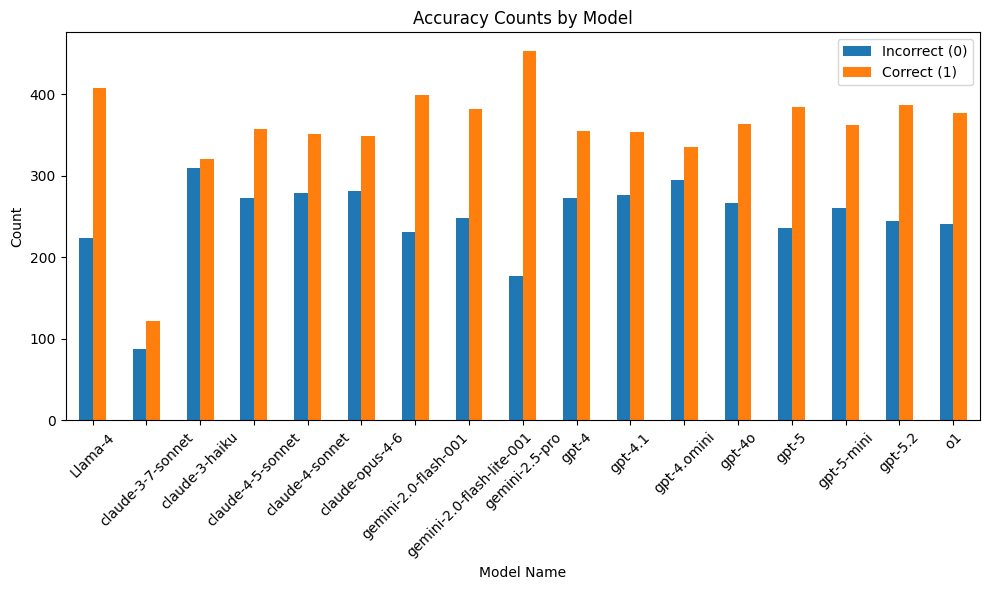

In [44]:
# Count 1's and 0's for each model
counts = metrics.groupby(['model_name', 'accuracy']).size().unstack(fill_value=0)

# Plot
counts.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Counts by Model')
plt.xlabel('Model Name')
plt.ylabel('Count')
plt.legend(['Incorrect (0)', 'Correct (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

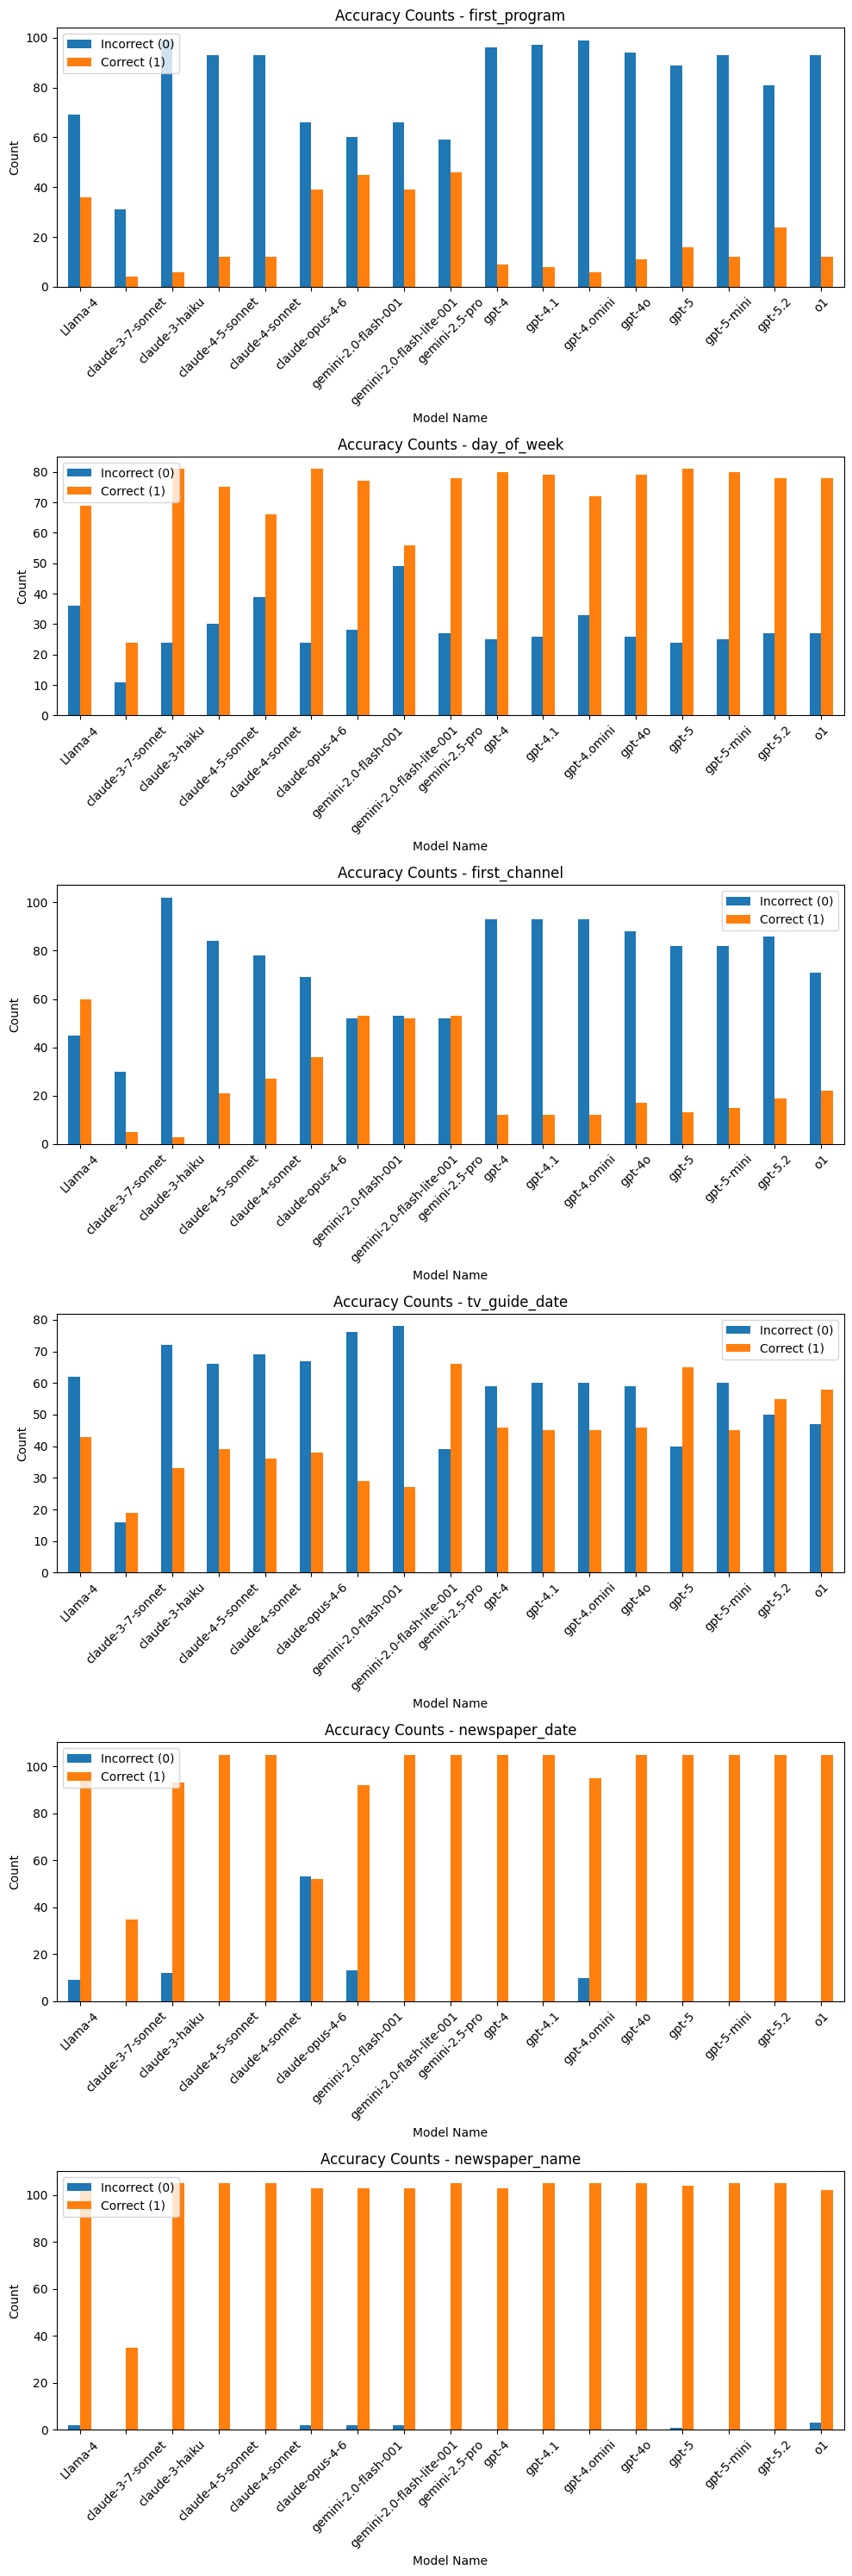

In [45]:
# Get unique benchmarks
benchmarks = metrics['benchmark_name'].unique().tolist()

# Create a subplot for each benchmark
fig, axes = plt.subplots(len(benchmarks), 1, figsize=(10, 5 * len(benchmarks)))

# If only one benchmark, make axes a list for consistency
if len(benchmarks) == 1:
    axes = [axes]

for ax, benchmark in zip(axes, benchmarks):
    # Filter data for this benchmark
    benchmark_df = metrics[metrics['benchmark_name'] == benchmark]
    
    # Count 1's and 0's for each model
    counts = benchmark_df.groupby(['model_name', 'accuracy']).size().unstack(fill_value=0)
    
    # Plot
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Accuracy Counts - {benchmark}')
    ax.set_xlabel('Model Name')
    ax.set_ylabel('Count')
    ax.legend(['Incorrect (0)', 'Correct (1)'])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

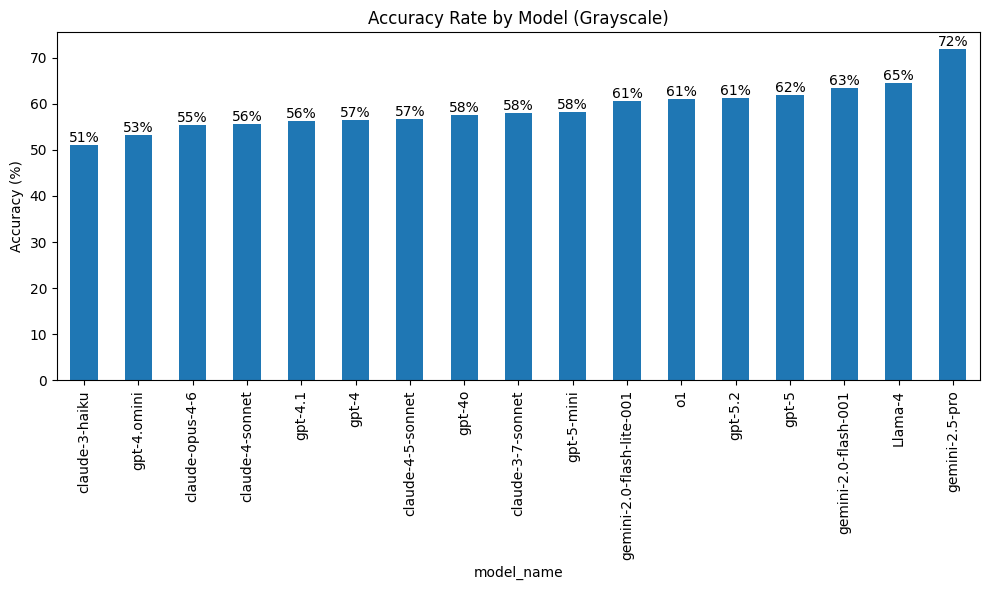

In [46]:
# Calculate percentage correct for each model
accuracy_pct = metrics.groupby('model_name')['accuracy'].mean() * 100

# Sort from lowest to highest
accuracy_pct_sorted = accuracy_pct.sort_values()

# Plot
accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Rate by Model (Grayscale)')
plt.xlabel('Model Name')
plt.ylabel('Accuracy (%)')

# add values to bars

ax = accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='%.0f%%')

#plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
benchmarks = metrics['benchmark_name'].unique().tolist()
benchmarks

['first_program',
 'day_of_week',
 'first_channel',
 'tv_guide_date',
 'newspaper_date',
 'newspaper_name']

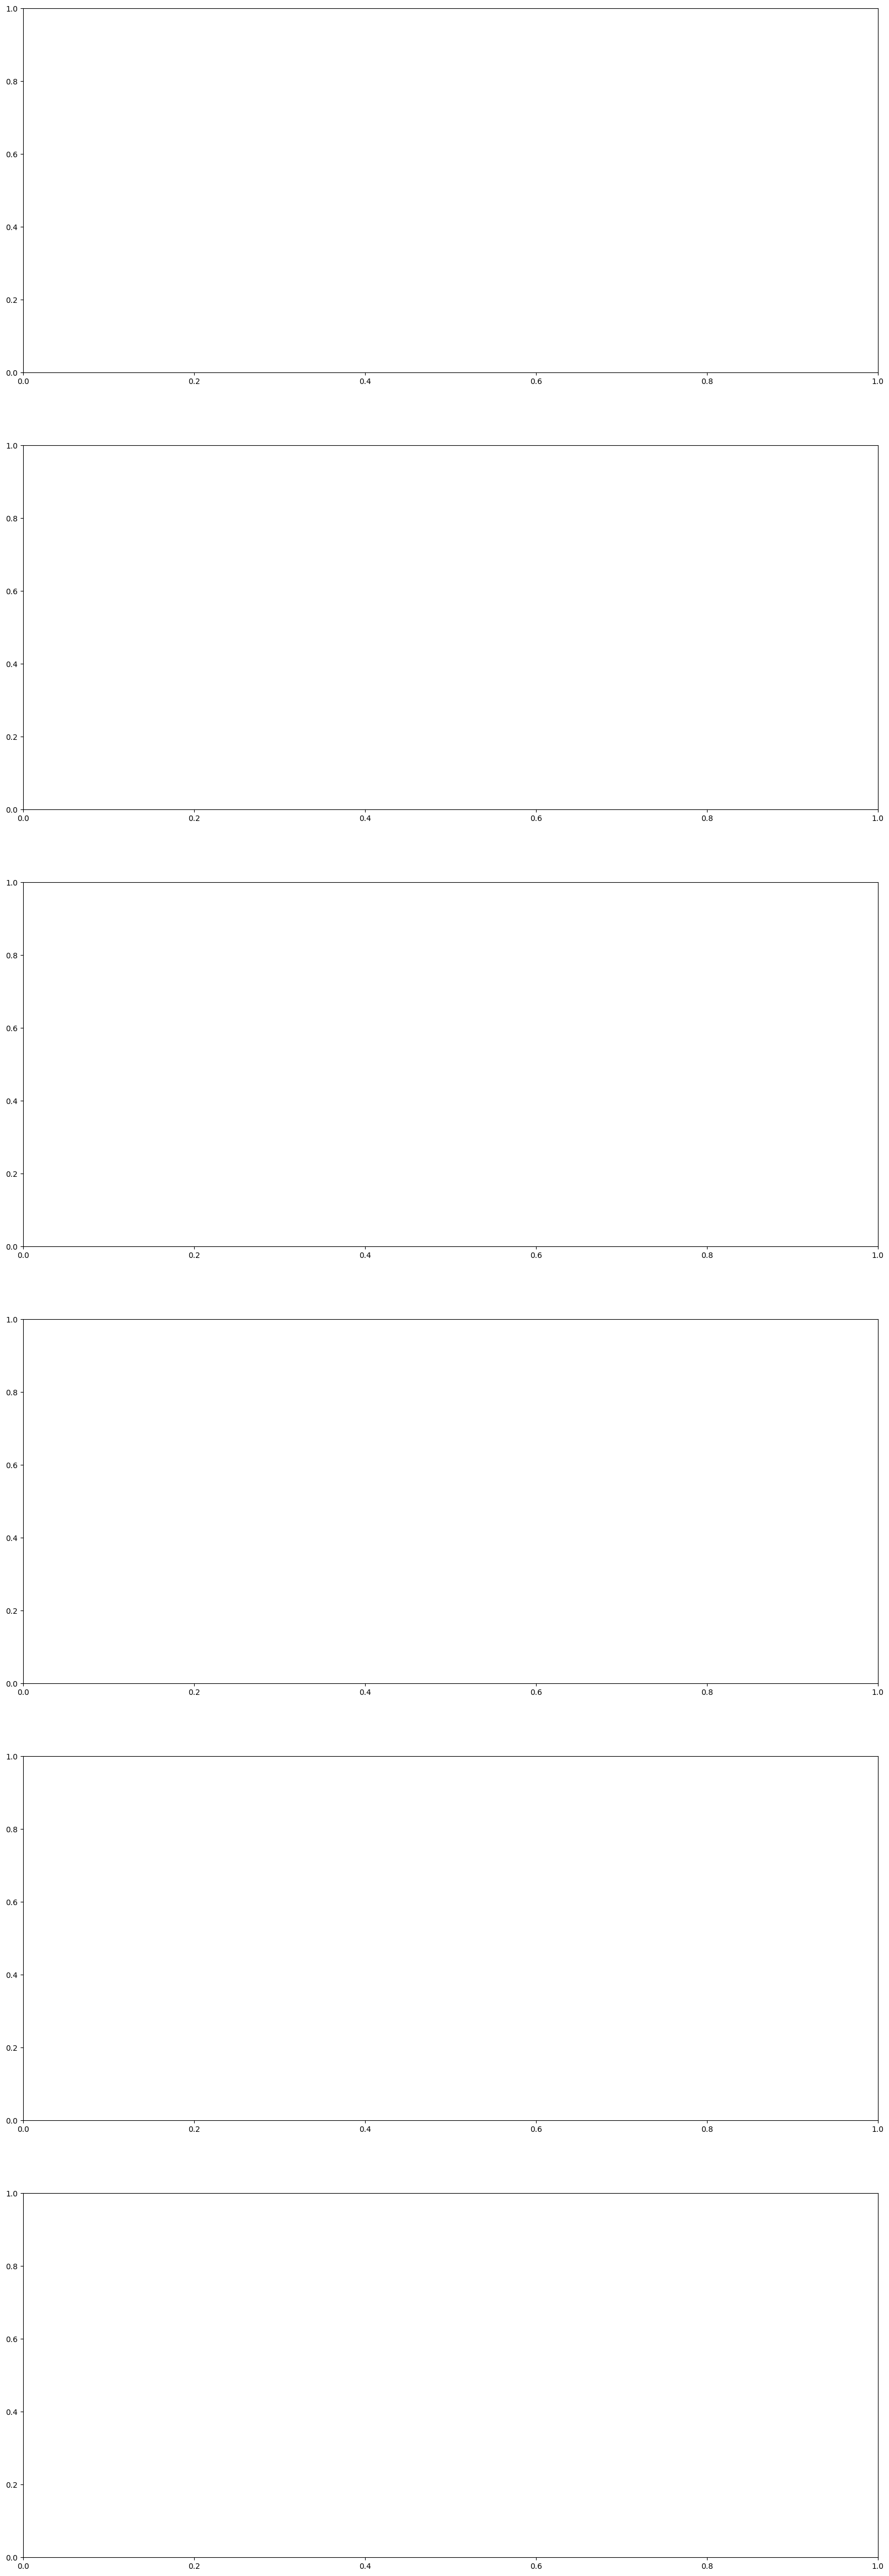

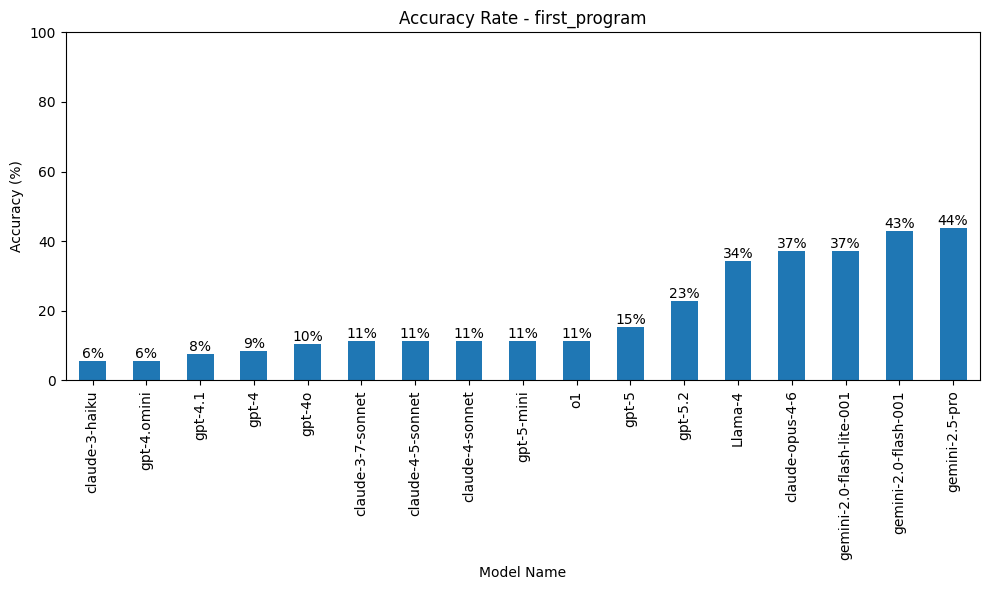

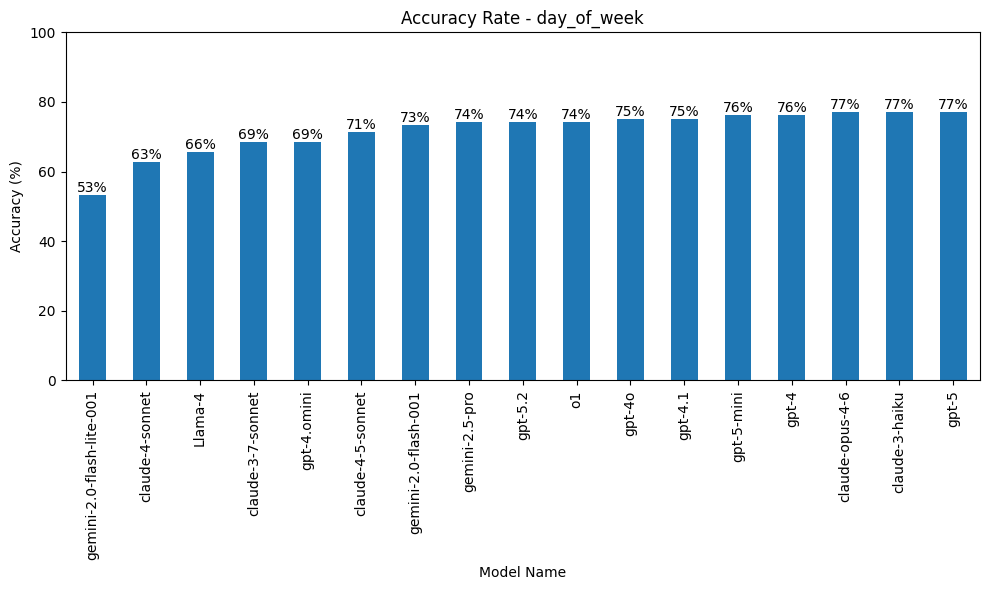

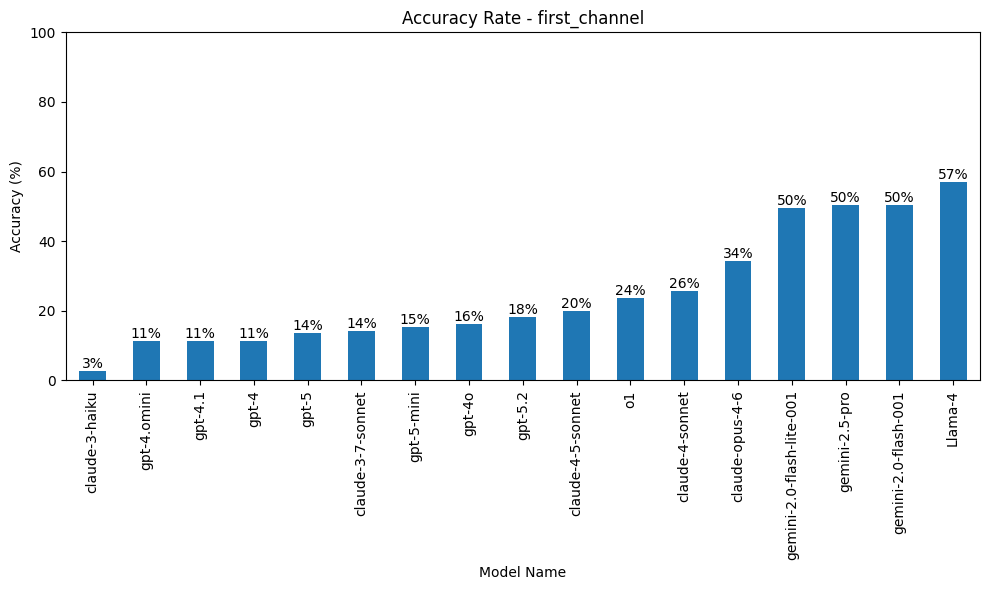

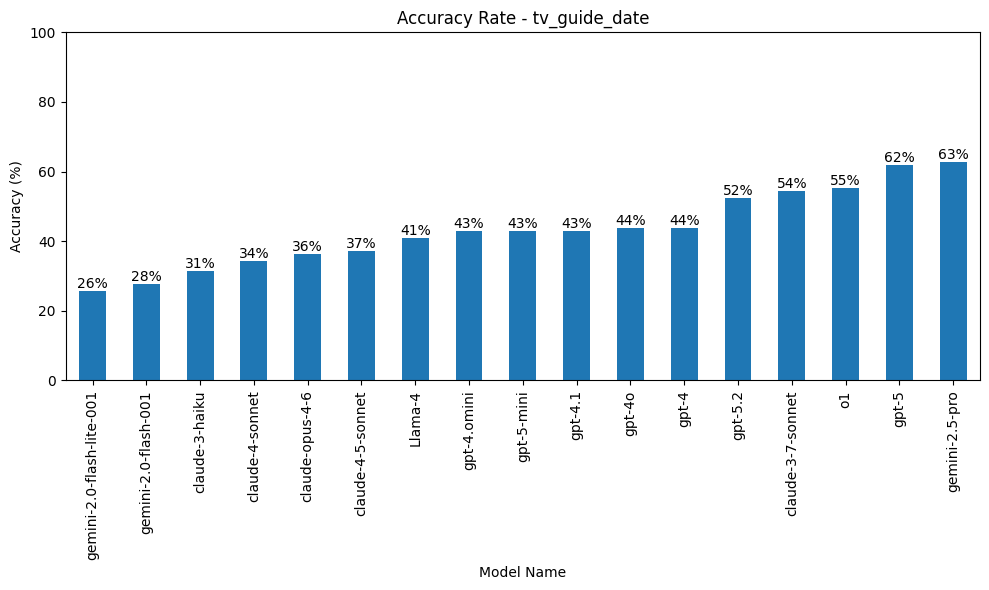

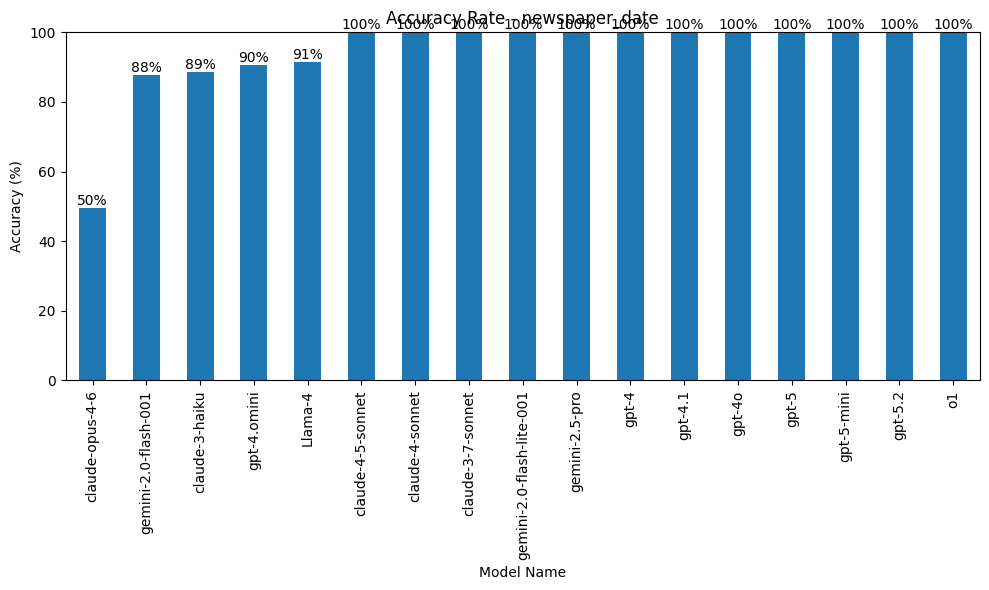

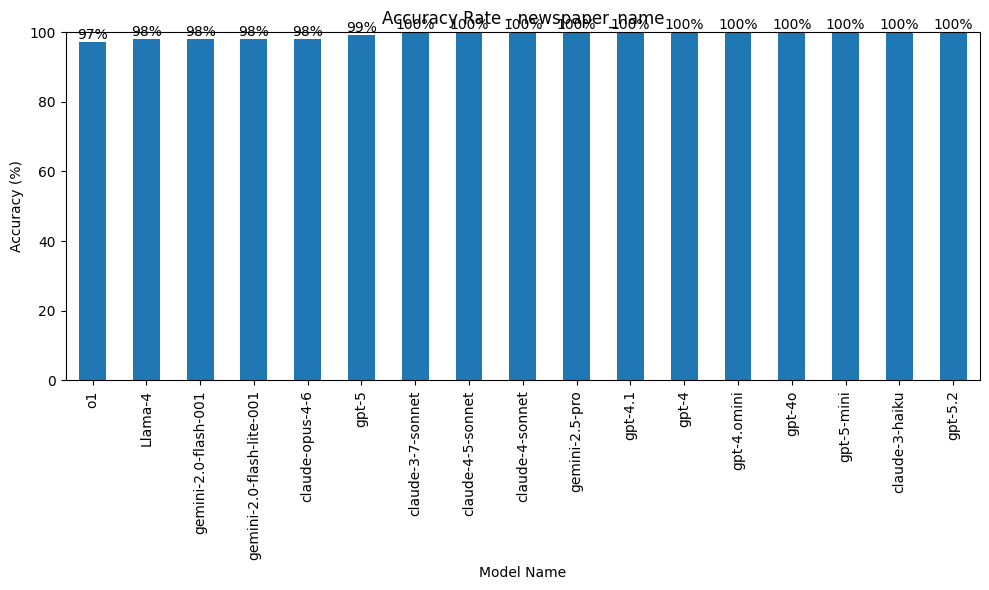

In [49]:
# Get unique benchmarks
benchmarks = metrics['benchmark_name'].unique().tolist()

# Create a subplot for each benchmark
fig, axes = plt.subplots(len(benchmarks), 1, figsize=(20, 10 * len(benchmarks)))

for benchmark in benchmarks:
    benchmark_df = metrics[metrics['benchmark_name'] == benchmark]
    accuracy_pct = benchmark_df.groupby('model_name')['accuracy'].mean() * 100
    accuracy_pct_sorted = accuracy_pct.sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    accuracy_pct_sorted.plot(kind='bar', ax=ax)
    ax.set_title(f'Accuracy Rate - {benchmark}')
    ax.set_xlabel('Model Name')
    ax.set_ylabel('Accuracy (%)')
    ax.bar_label(ax.containers[0], fmt='%.0f%%')
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()

In [15]:
for ax, benchmark in zip(axes, benchmarks):
    benchmark_df = metrics[metrics['benchmark_name'] == benchmark]
    accuracy_pct = benchmark_df.groupby('model_name')['accuracy'].mean() * 100
    accuracy_pct_sorted = accuracy_pct.sort_values()
    accuracy_pct_sorted.plot(kind='bar', ax=ax)
    ax.set_title(f'Accuracy Rate - {benchmark}')
    ax.set_xlabel('Model Name')
    ax.set_ylabel('Accuracy (%)')
    ax.bar_label(ax.containers[0], fmt='%.0f%%')
    ax.set_ylim(0, 100)

plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

# Results by Benchmark

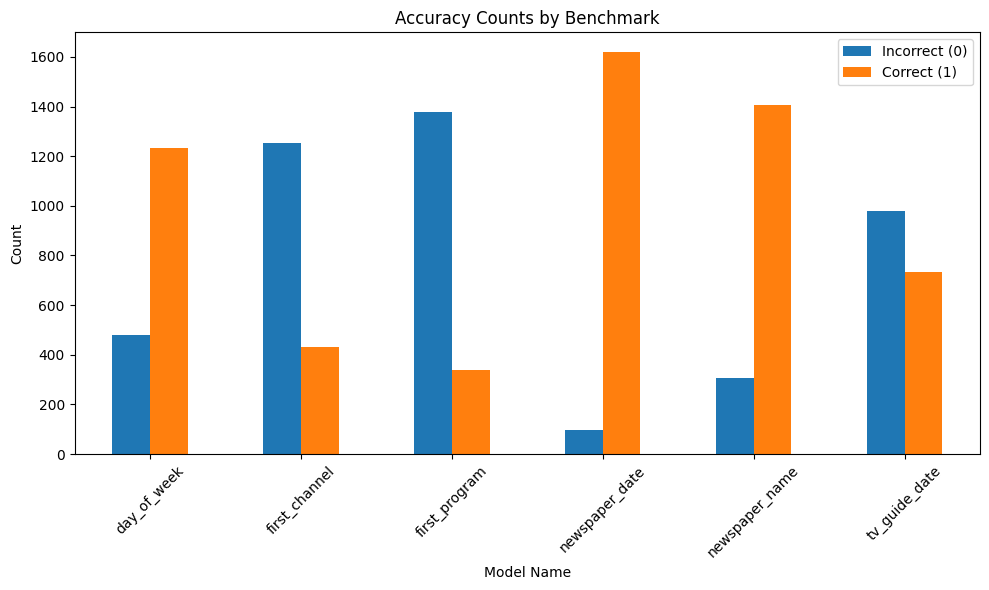

In [23]:
# Count 1's and 0's for each benchmark
counts = metrics.groupby(['benchmark_name', 'accuracy']).size().unstack(fill_value=0)

# Plot
counts.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Counts by Benchmark')
plt.xlabel('Model Name')
plt.ylabel('Count')
plt.legend(['Incorrect (0)', 'Correct (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

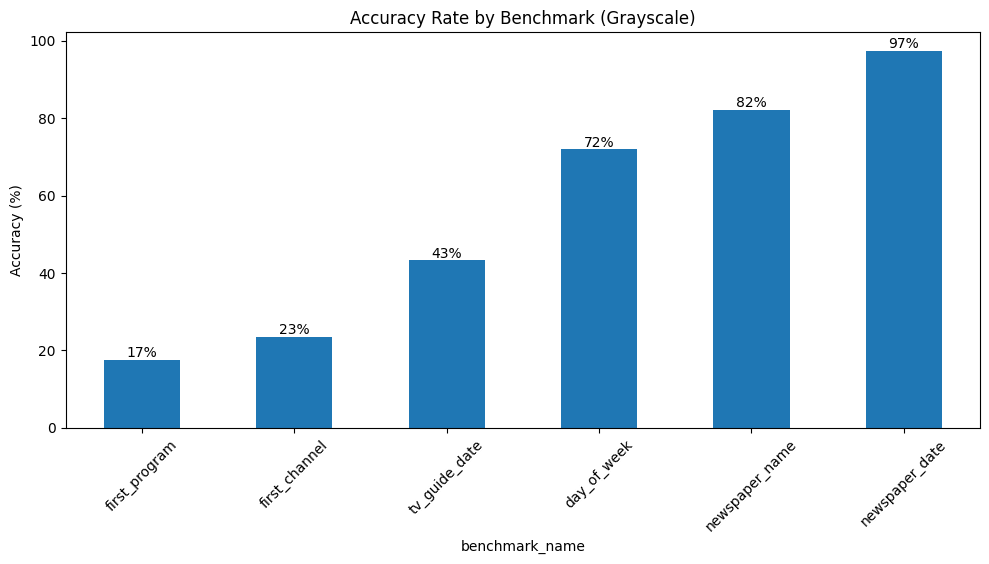

In [75]:
# Calculate percentage correct for each model
accuracy_pct = metrics.groupby('benchmark_name')['accuracy'].mean() * 100

# Sort from lowest to highest
accuracy_pct_sorted = accuracy_pct.sort_values()

# Plot
accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Rate by Benchmark (Grayscale)')
plt.xlabel('Benchmark Name')
plt.ylabel('Accuracy (%)')

plt.tight_layout()

# Add values to bars

ax = accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
ax.bar_label(ax.containers[0], fmt='%.0f%%')
plt.xticks(rotation=45)

plt.show()

# Results by Image

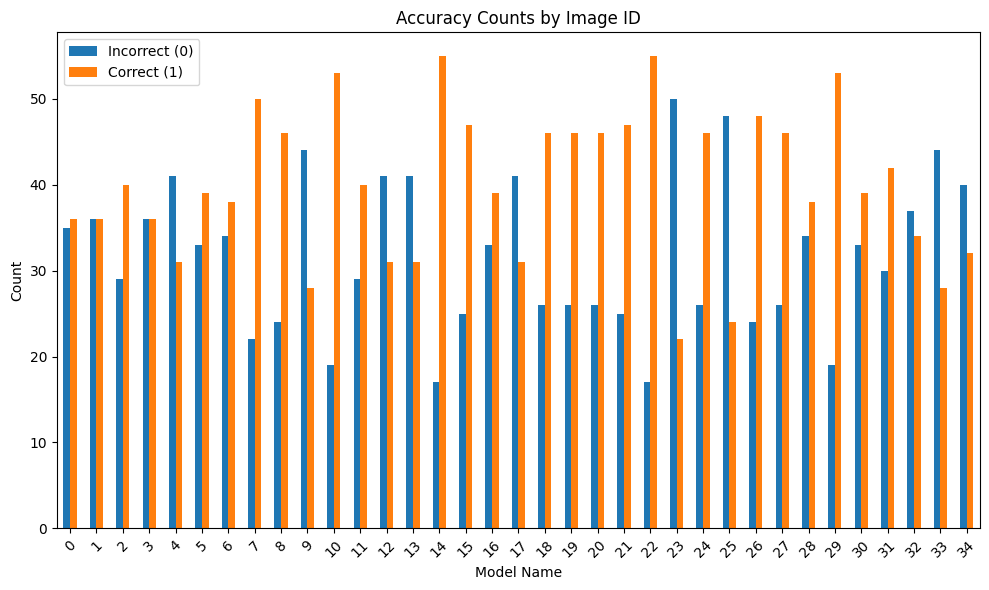

In [18]:
# Count 1's and 0's for each benchmark
counts = metrics.groupby(['image_id', 'accuracy']).size().unstack(fill_value=0)

# Plot
counts.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Counts by Image ID')
plt.xlabel('Model Name')
plt.ylabel('Count')
plt.legend(['Incorrect (0)', 'Correct (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

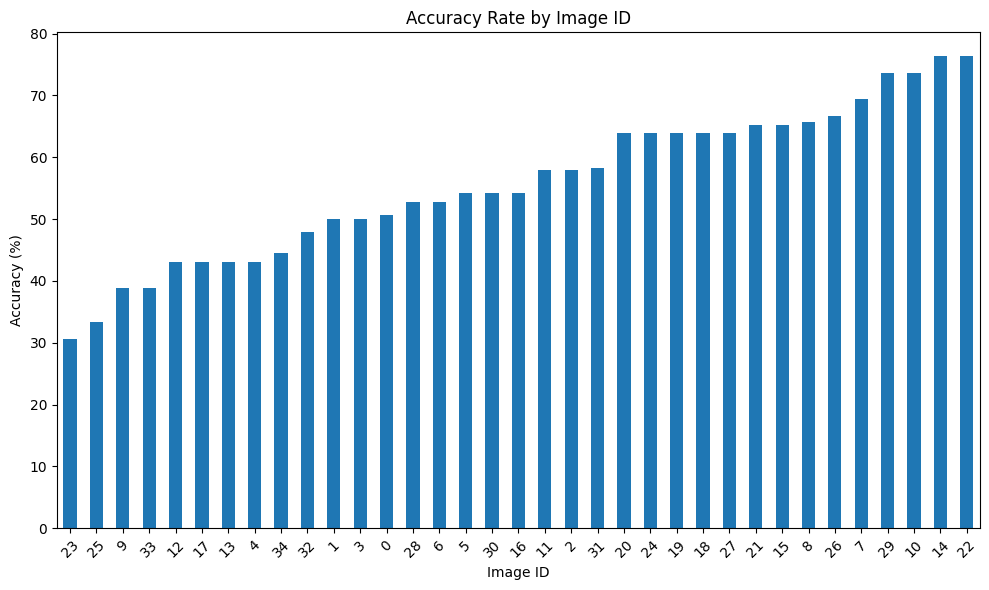

In [19]:
# Calculate percentage correct for each model
accuracy_pct = metrics.groupby('image_id')['accuracy'].mean() * 100

# Sort from lowest to highest
accuracy_pct_sorted = accuracy_pct.sort_values()

# Plot
accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Rate by Image ID')
plt.xlabel('Image ID')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

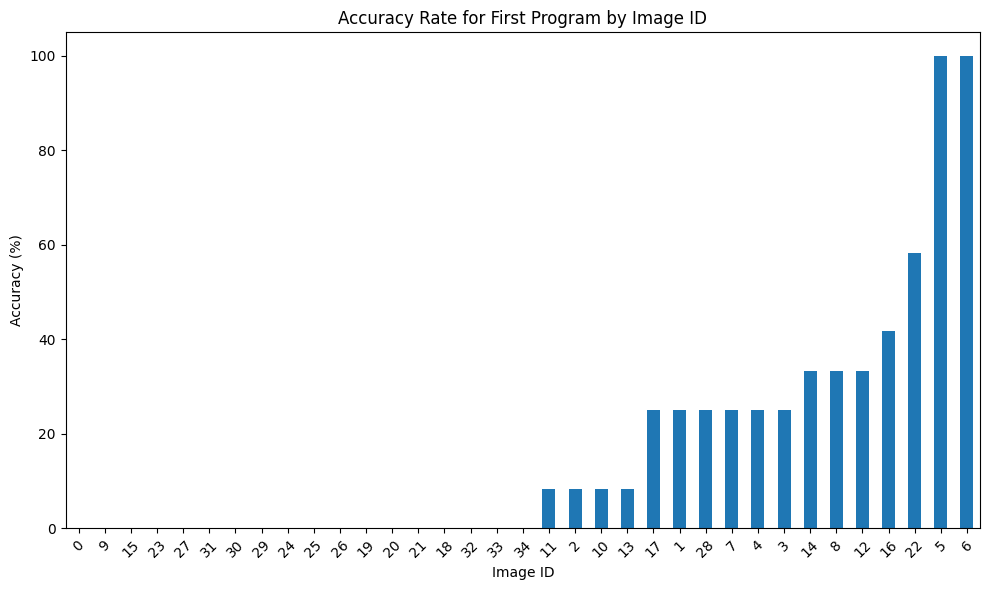

In [20]:
first_program_df = metrics[(metrics['benchmark_name'] == "first_program")]

# Calculate percentage correct for each model
accuracy_pct = first_program_df.groupby('image_id')['accuracy'].mean() * 100

# Sort from lowest to highest
accuracy_pct_sorted = accuracy_pct.sort_values()

# Plot
accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Rate for First Program by Image ID')
plt.xlabel('Image ID')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

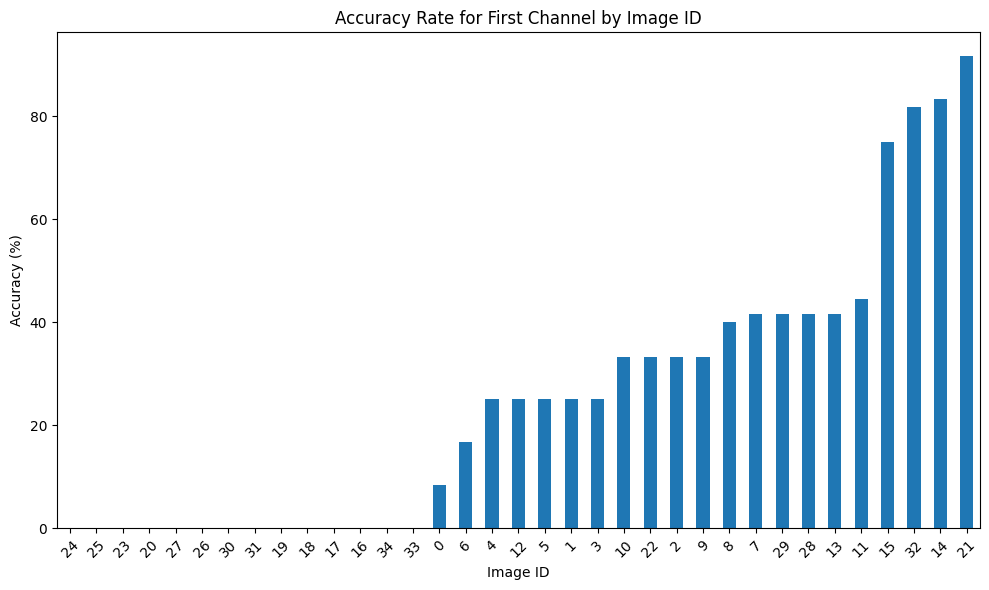

In [21]:
first_channel_df = metrics[(metrics['benchmark_name'] == "first_channel")]

# Calculate percentage correct for each model
accuracy_pct = first_channel_df.groupby('image_id')['accuracy'].mean() * 100

# Sort from lowest to highest
accuracy_pct_sorted = accuracy_pct.sort_values()

# Plot
accuracy_pct_sorted.plot(kind='bar', figsize=(10, 6))
plt.title('Accuracy Rate for First Channel by Image ID')
plt.xlabel('Image ID')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# First Program Errors

In [54]:
error_program_df = metrics[(metrics['benchmark_name'] == "first_program") & (metrics['accuracy'] == 0)]

error_program_df['is_correct'] = error_program_df.apply(lambda row: row['output'].lower() in row['ground_truth'].lower(), axis=1)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(error_program_df)


,task_id,output,model_name,model_id,image_id,benchmark_name,benchmark_id,run_id,completion_tokens,total_tokens,input_cost,output_cost,input_tokens,input_dollar_cost,output_dollar_cost,total_dollar_cost,ground_truth,accuracy,is_correct
0,3440,60 Minutes,gpt-5.2,17,10,first_program,4,1.0,15,1864,1.25,10.00,1849,0.002311,0.000150,0.002461,CBS 2 News Sunday (N),0,False
17,2005,The Tony Awards,gpt-4.omini,2,10,first_program,4,0.0,9,36937,0.15,0.60,36928,0.005539,0.000005,0.005545,CBS 2 News Sunday (N),0,False
19,2439,KHON 2 Morning News,o1,14,24,first_program,4,2.0,5337,5684,15.00,60.00,347,0.005205,0.320220,0.325425,Futurerama 8712,0,False
33,2177,Power Lunch,claude-3-haiku,7,7,first_program,4,0.0,37,2061,0.25,1.25,2024,0.000506,0.000046,0.000552,News at Noon,0,False
53,3739,Biography: Alan Alda,Llama-4,18,29,first_program,4,0.0,13,7676,0.35,1.15,7663,0.002682,0.000015,0.002697,Biography: Alan Alda 718318,0,True
58,2267,Good Morning America,claude-3-7-sonnet,9,27,first_program,4,0.0,37,2020,3.00,15.00,1983,0.005949,0.000555,0.006504,(6:00) News (CC) 34666,0,False
68,2354,CBS 2 News (N),gemini-2.0-flash-lite-001,12,9,first_program,4,2.0,18,3427,0.07,0.30,3409,0.000239,0.000005,0.000244,CBS 2 News Sunday (N),0,False
75,2243,Good Morning America,claude-3-7-sonnet,9,3,first_program,4,0.0,37,2020,3.00,15.00,1983,0.005949,0.000555,0.006504,Good Day Austin Saturday,0,False
81,1985,60 Minutes,gpt-4,1,25,first_program,4,1.0,8,1206,10.00,30.00,1198,0.011980,0.000240,0.012220,(6:00) News (CC) 52978,0,False
87,2329,Politically,gemini-2.0-flash-001,11,19,first_program,4,0.0,14,3423,0.15,0.60,3409,0.000511,0.000008,0.000520,Politically 9292145,0,True


In [55]:
error_program_df['is_correct'].value_counts()

is_correct
False    1070
True      308
Name: count, dtype: int64

In [60]:
1 - 308/1378

0.7764876632801161

In [57]:
error_channel_df = metrics[(metrics['benchmark_name'] == "first_channel") & (metrics['accuracy'] == 0)]

error_channel_df['is_correct'] = error_channel_df.apply(lambda row: row['output'].lower() in row['ground_truth'].lower(), axis=1)

error_channel_df['is_correct'].value_counts()

is_correct
False    815
True     438
Name: count, dtype: int64

In [61]:
1- 438/1253

0.650438946528332